In [1]:
# import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

In [2]:
# read the veteran dataset
df = pd.read_csv('dataset_ifn580_262_v1.csv')

# show all columns information
print(df.convert_dtypes().info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  string
 1   passanger             12684 non-null  string
 2   weather               12684 non-null  string
 3   temperature           12434 non-null  Int64 
 4   time                  12684 non-null  string
 5   coupon                12684 non-null  string
 6   expiration            12684 non-null  string
 7   gender                12684 non-null  string
 8   age                   12684 non-null  string
 9   maritalStatus         12684 non-null  string
 10  has_children          12684 non-null  Int64 
 11  education             12684 non-null  string
 12  occupation            12684 non-null  string
 13  income                12684 non-null  string
 14  car                   108 non-null    string
 15  Bar                   12577 non-null

In [3]:
print(df.map(type).nunique())
print("-" * 40)

for col in df.columns:
    print(df[col].apply(type).value_counts())
    print("-" * 40)

destination             1
passanger               1
weather                 1
temperature             1
time                    1
coupon                  1
expiration              1
gender                  1
age                     1
maritalStatus           1
has_children            1
education               1
occupation              1
income                  1
car                     2
Bar                     2
CoffeeHouse             2
CarryAway               2
RestaurantLessThan20    2
Restaurant20To50        2
toCoupon_GEQ5min        1
toCoupon_GEQ15min       1
toCoupon_GEQ25min       1
direction_same          1
direction_opp           1
is_accepted             1
dtype: int64
----------------------------------------
destination
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
passanger
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
weather
<class 'str'>    12684
Name: count, dtype: int64
-----------

In [4]:
## Assign Data Types
## looking at what kind of values can be found in each column
for name in df.columns:
    print(f'_{name}________________________________________')
    print(df[name].unique())

_destination________________________________________
['No Urgent Place' 'Home' 'Work']
_passanger________________________________________
['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
_weather________________________________________
['Sunny' 'Rainy' 'Snowy']
_temperature________________________________________
[55. 80. nan 30.]
_time________________________________________
['2PM' '10AM' '6PM' '7AM' '10PM']
_coupon________________________________________
['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
_expiration________________________________________
['1d' '2h']
_gender________________________________________
['Female' 'Male']
_age________________________________________
['21' '46' '26' '31' '41' '50plus' '36' 'below21']
_maritalStatus________________________________________
['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
_has_children________________________________________
[1 0]
_education________________________________________

In [5]:
## To Change
#time - datetime or an int (0-23)
#age - ordinal
#education - ordinal
#income - ordinal
#has_children - bool
# 20-25 - bool

In [6]:
# Changing the innapropriate data types

df.loc[df['time'] == '7AM', 'time'] = '7'
df.loc[df['time'] == '10AM', 'time'] = '10'
df.loc[df['time'] == '2PM', 'time'] = '14'
df.loc[df['time'] == '7AM', 'time'] = '7'
df.loc[df['time'] == '7AM', 'time'] = '7'

df['time'] = ...
['2PM' '10AM' '6PM' '7AM' '10PM']
df['age'] =  ...

edu_order = ['Some High School', 'High School Graduate', 'Some college - no degree',
            'Associates degree', 'Bachelors degree', 'Graduate degree (Masters or Doctorate)']
df['education'] = pd.Categorical(
    df["education"],
    categories=edu_order,
    ordered=True)

inc_order = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999',
            '$50000 - $62499', '$62500 - $74999', '$75000 - $87499', '$87500 - $99999',
            '$100000 or More']
df['income'] = pd.Categorical(
    df["income"],
    categories=inc_order,
    ordered=True)

df['has_children'] = df['has_children'].astype('boolean')
df['toCoupon_GEQ5min'] = df['toCoupon_GEQ5min'].astype('boolean')
df['toCoupon_GEQ15min'] = df['toCoupon_GEQ15min'].astype('boolean')
df['toCoupon_GEQ25min'] = df['toCoupon_GEQ25min'].astype('boolean')
df['direction_same'] = df['direction_same'].astype('boolean')
df['direction_opp'] = df['direction_opp'].astype('boolean')
df['is_accepted'] = df['is_accepted'].astype('boolean')  

In [7]:
print(df.convert_dtypes().info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   destination           12684 non-null  string  
 1   passanger             12684 non-null  string  
 2   weather               12684 non-null  string  
 3   temperature           12434 non-null  Int64   
 4   time                  12684 non-null  object  
 5   coupon                12684 non-null  string  
 6   expiration            12684 non-null  string  
 7   gender                12684 non-null  string  
 8   age                   12684 non-null  object  
 9   maritalStatus         12684 non-null  string  
 10  has_children          12684 non-null  boolean 
 11  education             12684 non-null  category
 12  occupation            12684 non-null  string  
 13  income                12684 non-null  category
 14  car                   108 non-null    string  
 15  Ba

In [8]:
## checking for data quality issues
# show cols with less than max / NAN values
NANcolumns_to_list = df.columns[df.count() < len(df)].tolist()
print(NANcolumns_to_list)

['temperature', 'car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']


In [9]:
for col in NANcolumns_to_list:
    unique_vals = df[col].unique().tolist()  # Get each unique values within col (includes NaN)
    unique_count = len(unique_vals)          # Count the number of unique values
    
    print(f"Column: {col}")
    print(f"Amount of unique values: {unique_count}")
    print(f"Unique values: {unique_vals}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

Column: temperature
Amount of unique values: 4
Unique values: [55.0, 80.0, nan, 30.0]
temperature
80.0    6399
55.0    3759
30.0    2276
NaN      250
Name: count, dtype: int64
----------------------------------------
Column: car
Amount of unique values: 6
Unique values: [nan, 'Scooter and motorcycle', 'crossover', 'Mazda5', 'do not drive', 'Car that is too old to install Onstar :D']
car
NaN                                         12576
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
Name: count, dtype: int64
----------------------------------------
Column: Bar
Amount of unique values: 6
Unique values: ['never', 'less1', '1~3', 'gt8', nan, '4~8']
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64
------------------------------

In [10]:
#In the car category, NAN comes to roughly 99.15%, as such it is useless in terms of real information
print(df['car'].value_counts(dropna=False))

car
NaN                                         12576
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
Name: count, dtype: int64


In [11]:
#Best option is to drop the car col as there is too little real information within the column
df = df.drop(columns=['car'])

In [12]:
NANcolumns_to_list = df.columns[df.count() < len(df)].tolist()
for col in NANcolumns_to_list:
    unique_vals = df[col].unique().tolist()  # Get each unique values within col (includes NaN)
    unique_count = len(unique_vals)          # Count the number of unique values
    
    print(f"Column: {col}")
    print(f"Amount of unique values: {unique_count}")
    print(f"Unique values: {unique_vals}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

Column: temperature
Amount of unique values: 4
Unique values: [55.0, 80.0, nan, 30.0]
temperature
80.0    6399
55.0    3759
30.0    2276
NaN      250
Name: count, dtype: int64
----------------------------------------
Column: Bar
Amount of unique values: 6
Unique values: ['never', 'less1', '1~3', 'gt8', nan, '4~8']
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64
----------------------------------------
Column: CoffeeHouse
Amount of unique values: 6
Unique values: ['never', 'less1', '4~8', '1~3', 'gt8', nan]
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64
----------------------------------------
Column: CarryAway
Amount of unique values: 6
Unique values: [nan, '4~8', '1~3', 'gt8', 'less1', 'never']
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64
----------------------------------

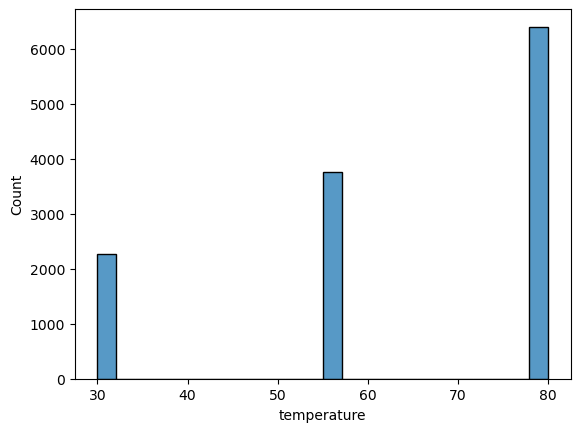

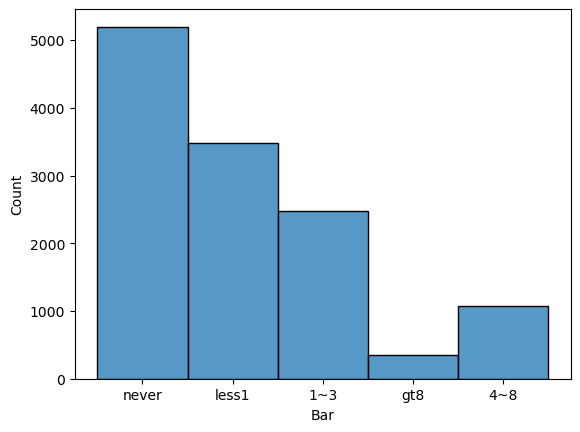

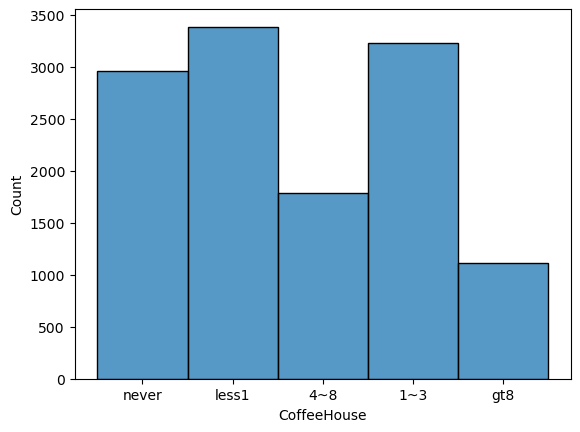

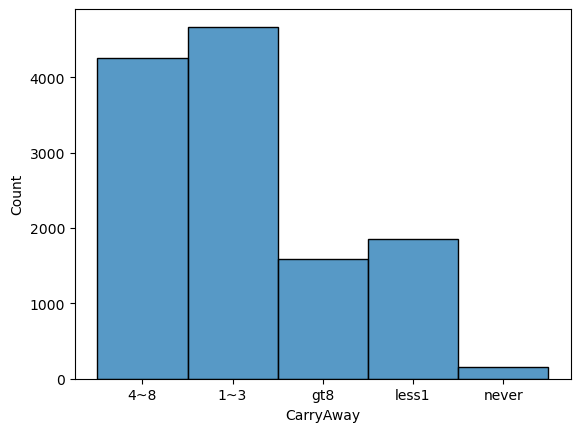

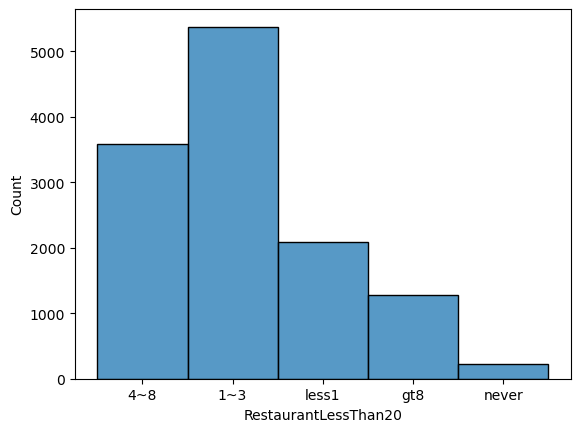

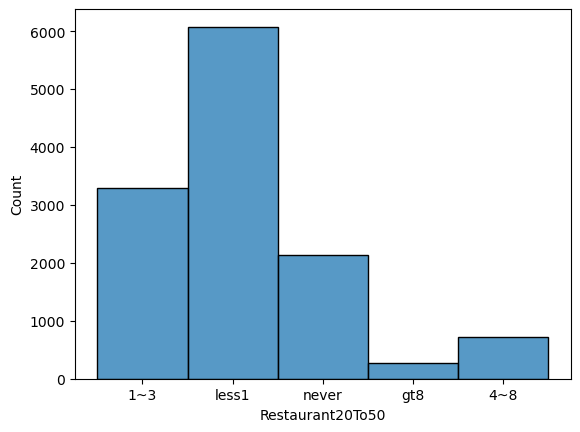

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in NANcolumns_to_list:
    dg = sns.histplot(df[col])
    plt.show()
    


In [14]:

for col in NANcolumns_to_list:
    df[col] = df[col].fillna(df[col].mode()[0])
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

temperature
80.0    6649
55.0    3759
30.0    2276
Name: count, dtype: int64
----------------------------------------
Bar
never    5304
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64
----------------------------------------
CoffeeHouse
less1    3602
1~3      3225
never    2962
4~8      1784
gt8      1111
Name: count, dtype: int64
----------------------------------------
CarryAway
1~3      4823
4~8      4258
less1    1856
gt8      1594
never     153
Name: count, dtype: int64
----------------------------------------
RestaurantLessThan20
1~3      5506
4~8      3580
less1    2093
gt8      1285
never     220
Name: count, dtype: int64
----------------------------------------
Restaurant20To50
less1    6266
1~3      3290
never    2136
4~8       728
gt8       264
Name: count, dtype: int64
----------------------------------------


In [15]:
NANcolumns_to_list = df.columns[df.count() < len(df)].tolist()
for col in NANcolumns_to_list:
    unique_vals = df[col].unique().tolist()  # Get each unique values within col (includes NaN)
    unique_count = len(unique_vals)          # Count the number of unique values
    
    print(f"Column: {col}")
    print(f"Amount of unique values: {unique_count}")
    print(f"Unique values: {unique_vals}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

In [16]:
#mixed numerical and textual
for col in df.columns:
    print(df[col].apply(type).value_counts())
    print("-" * 40)

destination
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
passanger
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
weather
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
temperature
<class 'float'>    12684
Name: count, dtype: int64
----------------------------------------
time
<class 'ellipsis'>    12684
Name: count, dtype: int64
----------------------------------------
coupon
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
expiration
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
gender
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
age
<class 'ellipsis'>    12684
Name: count, dtype: int64
----------------------------------------
maritalStatus
<class 'str'>    12684
Name: count, dtype: int64
---------------------------------------

In [17]:
df.map(type).nunique()

destination             1
passanger               1
weather                 1
temperature             1
time                    1
coupon                  1
expiration              1
gender                  1
age                     1
maritalStatus           1
has_children            1
education               1
occupation              1
income                  1
Bar                     1
CoffeeHouse             1
CarryAway               1
RestaurantLessThan20    1
Restaurant20To50        1
toCoupon_GEQ5min        1
toCoupon_GEQ15min       1
toCoupon_GEQ25min       1
direction_same          1
direction_opp           1
is_accepted             1
dtype: int64